# Demo: Outlier detection
Implement IQR (Interquartile Range) method to detect and treat outliers in the given bike.csv data set. 
- [Hints] Use Boxplot to detect outliers.

In [2]:
# import required packages
import pandas
import numpy as np

# upload the dataset
BIKE = pandas.read_csv("bike.csv")
BIKE

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


<Axes: >

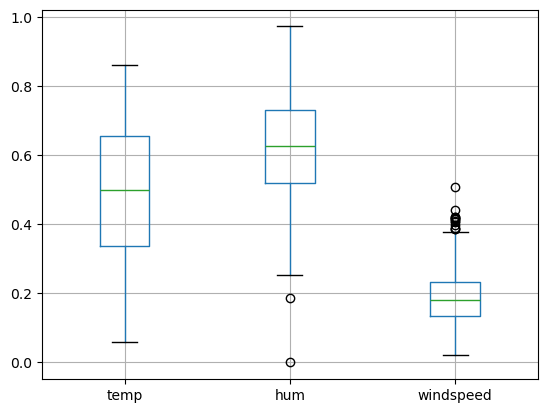

In [3]:
#Segregate the variables into numeric and categorical values.
numeric_col = ['temp','hum','windspeed']
categorical_col = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
BIKE.boxplot(numeric_col)

In [4]:
#Removal of Outliers
# Hints: use IQR concept to do it: Already covered during the class
for x in ['windspeed']:
    q75,q25 = np.percentile(BIKE.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
    
 #data points that lie outside of the lower and the upper bound with a NULL value.
    BIKE.loc[BIKE[x] < min,x] = np.nan
    BIKE.loc[BIKE[x] > max,x] = np.nan

In [5]:
#Having replaced the outliers with NaN, now check the sum of null values or missing 
# values using the below code
BIKE.isnull().sum()

instant        0
dteday         0
season         0
yr             0
mnth           0
holiday        0
weekday        0
workingday     0
weathersit     0
temp           0
atemp          0
hum            0
windspeed     13
casual         0
registered     0
cnt            0
dtype: int64

In [6]:
#[TODO] Drop the null values
BIKE = BIKE.dropna(axis = 0)

In [7]:
##check for the presence of missing or null values in the dataset
BIKE.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64